# 03 · Decision tree: `src/trees/_decision_tree.py`

Tests for `DecisionTree`, a classification tree that splits on information gain (entropy).

| Data | Source | What it tests |
|---|---|---|
| Hand-made toy sets | generated | the exact split threshold and the entropy criterion |
| Circle / informative-feature data | generated | non-linear boundaries, `feature_importances_` |
| Iris, Wine, Breast Cancer | scikit-learn, bundled | accuracy vs scikit-learn's `DecisionTreeClassifier(criterion="entropy")` |
| Mushroom (8 124 × 22, categorical) | **online** (UCI id 73) | label-encoded categorical features |

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, tree as sktree
from sklearn.model_selection import train_test_split

from _testkit import SEED, Checks, load_online, timed
from src.trees._decision_tree import DecisionTree

checks = Checks("03 decision tree")
rng = np.random.default_rng(SEED)

## 1. Split mechanics on toy data

For one feature `[1, 2, 3, 10, 11, 12]` with labels `[0, 0, 0, 1, 1, 1]`, the best split is the midpoint `6.5`. It separates the classes perfectly, giving a gain of 1 bit.

In [2]:
X_toy = np.array([[1], [2], [3], [10], [11], [12]], dtype=float)
y_toy = np.array([0, 0, 0, 1, 1, 1])
t = DecisionTree(max_depth=3).fit(X_toy, y_toy)
checks.check("root splits on feature 0", t.root_.feature_index == 0)
checks.close("root threshold is the midpoint 6.5", t.root_.threshold, 6.5)
checks.check("one split suffices (depth 1)", t.get_depth() == 1)
checks.check("children are pure leaves", t.root_.left.is_leaf and t.root_.right.is_leaf)

# Feature 1 is pure noise, feature 0 decides the label → the tree must pick feature 0.
X_two = np.column_stack([np.repeat([0.0, 1.0], 50), rng.normal(size=100)])
y_two = np.repeat([0, 1], 50)
checks.check("picks the informative feature over noise", DecisionTree().fit(X_two, y_two).root_.feature_index == 0)

pure = DecisionTree().fit(np.ones((5, 2)), np.zeros(5, dtype=int))
checks.check("pure node becomes a single leaf (depth 0)", pure.get_depth() == 0 and pure.root_.is_leaf)

✅ root splits on feature 0
✅ root threshold is the midpoint 6.5  (max |Δ| = 0.00e+00)
✅ one split suffices (depth 1)
✅ children are pure leaves
✅ picks the informative feature over noise
✅ pure node becomes a single leaf (depth 0)


True

## 2. Hyperparameters do what they say

In [3]:
X_bc, y_bc = datasets.load_breast_cancer(return_X_y=True)

for d in [1, 2, 4, 8]:
    checks.check(f"max_depth={d} respected", DecisionTree(max_depth=d).fit(X_bc, y_bc).get_depth() <= d)

deep = DecisionTree(max_depth=50).fit(X_bc, y_bc)
checks.close("unlimited depth memorises the training set", np.mean(deep.predict(X_bc) == y_bc), 1.0)
checks.check("tree_depth attribute == get_depth()", deep.tree_depth == deep.get_depth())

shallow = DecisionTree(max_depth=50, min_samples_split=200).fit(X_bc, y_bc)
checks.check("large min_samples_split gives a shallower tree", shallow.get_depth() < deep.get_depth(),
             f"{shallow.get_depth()} < {deep.get_depth()}")

a = DecisionTree(max_depth=6, max_features="sqrt", random_state=1).fit(X_bc, y_bc).predict(X_bc)
b = DecisionTree(max_depth=6, max_features="sqrt", random_state=1).fit(X_bc, y_bc).predict(X_bc)
checks.check("max_features + random_state is reproducible", np.array_equal(a, b))
for mf in ["sqrt", "log2", 3, 0.5]:
    checks.check(f"max_features={mf!r} trains", DecisionTree(max_features=mf, random_state=0).fit(X_bc, y_bc).get_depth() >= 1)
checks.raises("unknown max_features string raises", ValueError,
              lambda: DecisionTree(max_features="bogus").fit(X_bc, y_bc))

✅ max_depth=1 respected
✅ max_depth=2 respected
✅ max_depth=4 respected
✅ max_depth=8 respected
✅ unlimited depth memorises the training set  (max |Δ| = 0.00e+00)
✅ tree_depth attribute == get_depth()
✅ large min_samples_split gives a shallower tree  (4 < 7)
✅ max_features + random_state is reproducible
✅ max_features='sqrt' trains
✅ max_features='log2' trains
✅ max_features=3 trains
✅ max_features=0.5 trains
✅ unknown max_features string raises  (ValueError: Unknown max_features option: 'bogus')


True

### Overfitting curve

As depth grows, training accuracy climbs to 100 % while test accuracy levels off. This is the bias-variance trade-off that `max_depth` controls.

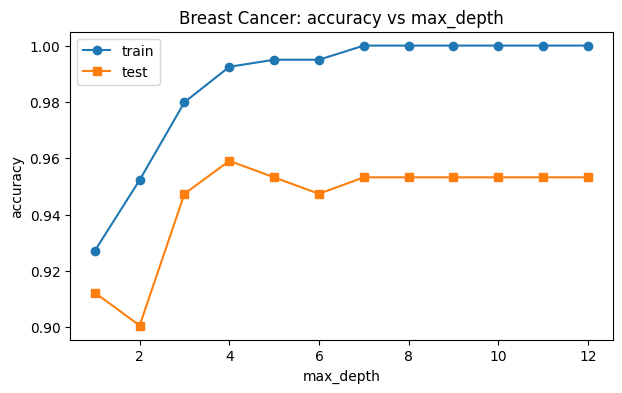

✅ training accuracy never decreases with depth


True

In [4]:
Xtr, Xte, ytr, yte = train_test_split(X_bc, y_bc, test_size=0.3, random_state=SEED, stratify=y_bc)
depths = range(1, 13)
tr_acc, te_acc = [], []
for d in depths:
    m = DecisionTree(max_depth=d).fit(Xtr, ytr)
    tr_acc.append(np.mean(m.predict(Xtr) == ytr)); te_acc.append(np.mean(m.predict(Xte) == yte))

plt.figure(figsize=(7, 4))
plt.plot(depths, tr_acc, "o-", label="train"); plt.plot(depths, te_acc, "s-", label="test")
plt.title("Breast Cancer: accuracy vs max_depth"); plt.xlabel("max_depth"); plt.ylabel("accuracy"); plt.legend()
plt.show()
checks.check("training accuracy never decreases with depth", np.all(np.diff(tr_acc) >= -1e-12))

## 3. Accuracy vs scikit-learn on real datasets

The reference is `DecisionTreeClassifier(criterion="entropy")` with the same `max_depth`. Tie-breaking between equally good splits can differ, so we compare accuracy, not individual trees.

In [5]:
rows = []
for name, loader in [("Iris", datasets.load_iris), ("Wine", datasets.load_wine), ("Breast Cancer", datasets.load_breast_cancer)]:
    X, y = loader(return_X_y=True)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
    ours = DecisionTree(max_depth=5).fit(Xtr, ytr)
    ref = sktree.DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=SEED).fit(Xtr, ytr)
    acc_o, acc_r = np.mean(ours.predict(Xte) == yte), ref.score(Xte, yte)
    rows.append({"dataset": name, "ours": acc_o, "sklearn": acc_r,
                 "agreement": np.mean(ours.predict(Xte) == ref.predict(Xte))})
    checks.at_most(f"{name}: |ours − sklearn| test accuracy", abs(acc_o - acc_r), 0.06)
    checks.at_least(f"{name}: test accuracy", acc_o, 0.85)
display(pd.DataFrame(rows).round(3))

✅ Iris: |ours − sklearn| test accuracy  (0.0222 ≤ 0.06)
✅ Iris: test accuracy  (0.9111 ≥ 0.85)
✅ Wine: |ours − sklearn| test accuracy  (0.0000 ≤ 0.06)
✅ Wine: test accuracy  (0.9074 ≥ 0.85)
✅ Breast Cancer: |ours − sklearn| test accuracy  (0.0000 ≤ 0.06)
✅ Breast Cancer: test accuracy  (0.9532 ≥ 0.85)


,dataset,ours,sklearn,agreement
0,Iris,0.911,0.889,0.978
1,Wine,0.907,0.907,1.000
2,Breast Cancer,0.953,0.953,1.000


## 4. Feature importances

On data where only features 0 and 1 matter (a circular class boundary), they should hold almost all the importance.

> We avoid XOR on purpose: no single XOR feature has any information gain on its own, so a *greedy* tree can start by splitting on noise. That is a known limitation of greedy trees, not a bug.

On Iris, petal length and petal width are almost interchangeable (r = 0.96), so two correct trees can give the importance to different petal features. We therefore check that the **petal features together** dominate in both trees. On Wine, where there are no such ties, the importance vectors themselves should agree.

✅ importances sum to 1  (max |Δ| = 0.00e+00)
✅ importances are non-negative
✅ circle: features 0 + 1 hold the importance  (1.0000 ≥ 0.9)
circle train accuracy  ours: 0.9483 | sklearn: 0.9483  (axis-aligned splits approximate a circle)
✅ circle: non-linear boundary learned (train accuracy)  (0.9483 ≥ 0.93)
✅ circle: |ours − sklearn| train accuracy  (0.0000 ≤ 0.03)
✅ Iris: petal features hold ≥ 95 % of importance (ours)  (0.9883 ≥ 0.95)
✅ Iris: petal features hold ≥ 95 % of importance (sklearn)  (0.9883 ≥ 0.95)
✅ Wine: importances correlate with sklearn  (0.9968 ≥ 0.9)


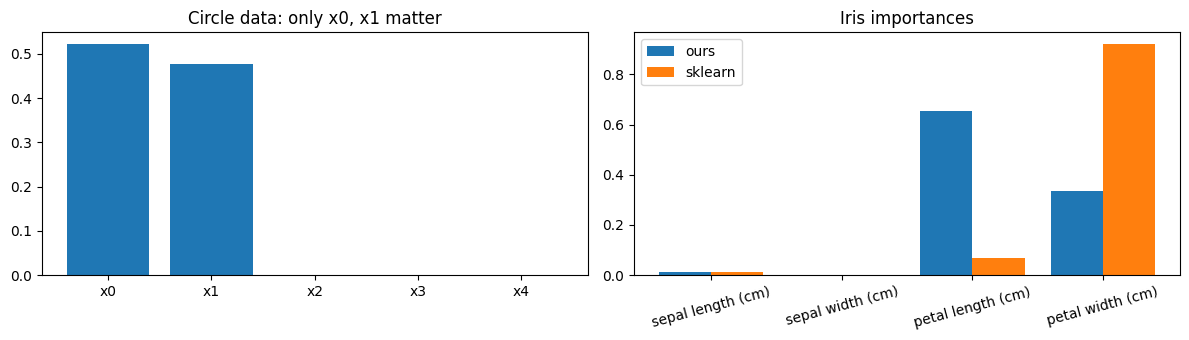

In [6]:
X_circ = np.random.default_rng(0).uniform(-1, 1, size=(600, 5))
y_circ = (X_circ[:, 0] ** 2 + X_circ[:, 1] ** 2 < 0.5).astype(int)
circ_tree = DecisionTree(max_depth=6).fit(X_circ, y_circ)
imp = circ_tree.feature_importances_
checks.close("importances sum to 1", imp.sum(), 1.0)
checks.check("importances are non-negative", (imp >= 0).all())
checks.at_least("circle: features 0 + 1 hold the importance", imp[0] + imp[1], 0.9)
circ_acc = np.mean(circ_tree.predict(X_circ) == y_circ)
circ_ref = sktree.DecisionTreeClassifier(criterion="entropy", max_depth=6, random_state=0).fit(X_circ, y_circ).score(X_circ, y_circ)
print(f"circle train accuracy  ours: {circ_acc:.4f} | sklearn: {circ_ref:.4f}  (axis-aligned splits approximate a circle)")
checks.at_least("circle: non-linear boundary learned (train accuracy)", circ_acc, 0.93)
checks.at_most("circle: |ours − sklearn| train accuracy", abs(circ_acc - circ_ref), 0.03)

X_iris, y_iris = datasets.load_iris(return_X_y=True)
imp_ours = DecisionTree(max_depth=4).fit(X_iris, y_iris).feature_importances_
imp_ref = sktree.DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=0).fit(X_iris, y_iris).feature_importances_
checks.at_least("Iris: petal features hold ≥ 95 % of importance (ours)", imp_ours[2] + imp_ours[3], 0.95)
checks.at_least("Iris: petal features hold ≥ 95 % of importance (sklearn)", imp_ref[2] + imp_ref[3], 0.95)
X_wine, y_wine = datasets.load_wine(return_X_y=True)
checks.at_least("Wine: importances correlate with sklearn",
                np.corrcoef(DecisionTree(max_depth=4).fit(X_wine, y_wine).feature_importances_,
                            sktree.DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=0)
                            .fit(X_wine, y_wine).feature_importances_)[0, 1], 0.9)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].bar(range(5), imp); ax[0].set(title="Circle data: only x0, x1 matter", xticks=range(5), xticklabels=[f"x{i}" for i in range(5)])
w = 0.4; names = datasets.load_iris().feature_names
ax[1].bar(np.arange(4) - w / 2, imp_ours, w, label="ours"); ax[1].bar(np.arange(4) + w / 2, imp_ref, w, label="sklearn")
ax[1].set(title="Iris importances", xticks=range(4)); ax[1].set_xticklabels(names, rotation=15); ax[1].legend()
plt.tight_layout(); plt.show()

### Decision regions (2 Iris features)

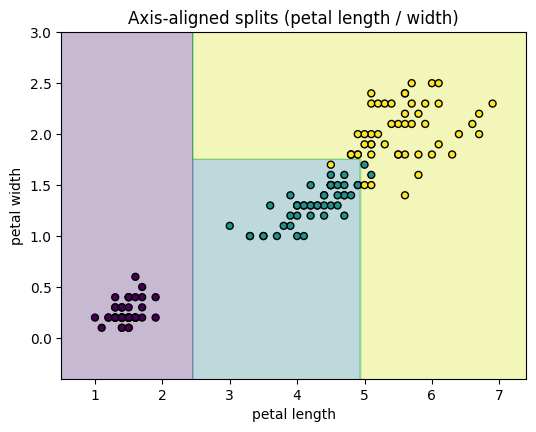

✅ Iris (2 features, depth 3): training accuracy  (0.9733 ≥ 0.95)


True

In [7]:
X2 = X_iris[:, 2:4]
m2 = DecisionTree(max_depth=3).fit(X2, y_iris)
xx, yy = np.meshgrid(np.linspace(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5, 300),
                     np.linspace(X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5, 300))
Z = m2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(6, 4.5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis"); plt.scatter(X2[:, 0], X2[:, 1], c=y_iris, cmap="viridis", edgecolor="k", s=25)
plt.title("Axis-aligned splits (petal length / width)"); plt.xlabel("petal length"); plt.ylabel("petal width"); plt.show()
checks.at_least("Iris (2 features, depth 3): training accuracy", np.mean(m2.predict(X2) == y_iris), 0.95)

## 5. Real data (online): Mushroom

8 124 mushrooms described by 22 **categorical** attributes (odor, gill size, …) and labelled edible or poisonous. The categories are label-encoded to integers, which is how the tree expects categorical input. A good tree classifies this dataset almost perfectly.

In [8]:
def _mushroom():
    from ucimlrepo import fetch_ucirepo
    d = fetch_ucirepo(id=73)
    X = d.data.features.apply(lambda col: pd.factorize(col)[0]).to_numpy()   # missing → -1
    y = (d.data.targets.iloc[:, 0] == "p").to_numpy().astype(int)
    return X, y, list(d.data.features.columns)

mush, online = load_online("Mushroom (UCI 73)", _mushroom)
if online:
    Xm, ym, mush_cols = mush
    Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=0.3, random_state=SEED, stratify=ym)
    with timed("DecisionTree fit on 5 686 rows"):
        mt = DecisionTree(max_depth=8).fit(Xtr, ytr)
    acc_m = np.mean(mt.predict(Xte) == yte)
    top = np.argsort(mt.feature_importances_)[::-1][:3]
    print("most important attributes:", [mush_cols[i] for i in top])
    print(f"test accuracy: {acc_m:.4f}")
    checks.at_least("Mushroom: test accuracy", acc_m, 0.99)
else:
    checks.skip("Mushroom checks", "dataset unavailable offline")

🌐 Mushroom (UCI 73): downloaded / loaded from cache
⏱️ DecisionTree fit on 5 686 rows: 0.03s
most important attributes: ['odor', 'spore-print-color', 'gill-size']
test accuracy: 1.0000
✅ Mushroom: test accuracy  (1.0000 ≥ 0.99)


## 6. API contract

In [9]:
m = DecisionTree()
checks.check("fit() returns self", m.fit(X_iris, y_iris) is m)
checks.check("classes_ are the sorted labels", np.array_equal(m.classes_, [0, 1, 2]))
y_str = np.array(["setosa", "versicolor", "virginica"])[y_iris]
ms = DecisionTree(max_depth=3).fit(X_iris, y_str)
checks.check("string labels are supported", set(ms.predict(X_iris)) <= set(y_str) and ms.predict(X_iris).dtype.kind == "U")
checks.check("predict returns one label per sample", m.predict(X_iris).shape == (len(X_iris),))

✅ fit() returns self
✅ classes_ are the sorted labels
✅ string labels are supported
✅ predict returns one label per sample


True

## Summary

In [10]:
checks.summary()

03 decision tree: 40 passed, 0 failed, 0 skipped, 0 known bug(s) (40 checks)


,check,status,detail
0,root splits on feature 0,pass,
1,root threshold is the midpoint 6.5,pass,max |Δ| = 0.00e+00
2,one split suffices (depth 1),pass,
3,children are pure leaves,pass,
4,picks the informative feature over noise,pass,
5,pure node becomes a single leaf (depth 0),pass,
6,max_depth=1 respected,pass,
7,max_depth=2 respected,pass,
8,max_depth=4 respected,pass,
9,max_depth=8 respected,pass,
